# 8주차: 실전 딥러닝 2
## — Batch Normalization & Softmax 다중분류

> **이전 주차 복습**: 7주차에서 DataLoader, Momentum, Adam, LR Scheduler를 배웠습니다.  
> 오늘은 **새 내용 2가지** — Batch Normalization과 Softmax 다중분류를 마저 다루겠습니다



## 📋 목차

**Part 1 (강의용 — 영상)**

1. [Batch Normalization](#section1)
2. [Softmax 다중분류](#section2)
3. [두 기법을 합친 완성 모델](#section3)

**Part 2 (실습용 — 100분)**

- [A] 한 줄 채우기 (10문제)
- [B] 여러 줄 채우기 (1문제)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)
print("Ready!")


PyTorch version: 2.10.0+cu128
Ready!


---
<a id="section1"></a>
## 1. Batch Normalization

### 1-1. 왜 필요한가? — Internal Covariate Shift

딥러닝에서 층이 깊어질수록 문제가 생깁니다.  
앞 층의 가중치가 업데이트되면, 뒤 층이 받는 **입력 분포가 계속 바뀝니다**. (한 층이 배운 내용이 바뀌어서 다음 층이 매번 다른 입력을 다시 적응해야 하는 상황) 이를 **Internal Covariate Shift** 라고 합니다.

결과:
- 학습률을 크게 쓰기 어려움 → 수렴 느림
- 가중치 초기화에 매우 민감
- Vanishing/Exploding Gradient 악화

### 1-2. 아이디어: 각 층의 입력을 정규화하자

$$\hat{x}^{(k)} = \frac{x^{(k)} - \mu_\mathcal{B}^{(k)}}{\sqrt{(\sigma_\mathcal{B}^{(k)})^2 + \epsilon}}$$

$$y^{(k)} = \gamma^{(k)} \hat{x}^{(k)} + \beta^{(k)}$$

- $\mu_\mathcal{B}$, $\sigma_\mathcal{B}$: 현재 **미니배치**의 평균·표준편차
- $\epsilon$: 분모 0 방지 (보통 1e-5)
- $\gamma$, $\beta$: **학습 가능한** 스케일·시프트 파라미터

> **핵심**: 정규화 후 $\gamma$, $\beta$로 모델이 필요한 분포를 스스로 학습합니다.  
> 완전히 정규화된 상태가 항상 최선이 아닐 수 있기 때문입니다.

### 1-3. 훈련 vs 추론 모드의 차이

| 모드 | 평균·분산 계산 방법 |
|------|-------------------|
| 훈련 (`model.train()`) | 현재 미니배치의 평균·분산 사용 |
| 추론 (`model.eval()`) | 훈련 중 누적한 **이동 평균(running mean/var)** 사용 |

> 이것이 바로 BN을 쓸 때 `model.train()` / `model.eval()` 전환이 **필수**인 이유입니다.  
> 5주차에서 습관 형성을 강조했던 것, 기억하시죠?

### 1-4. PyTorch에서 사용법

```python
nn.BatchNorm1d(num_features)   # MLP (1D feature)
nn.BatchNorm2d(num_channels)   # CNN (2D feature map)
```

**위치**: 보통 Linear/Conv 다음, 활성화 함수 이전에 배치합니다.

```python
nn.Sequential(
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),   # ← 여기
    nn.ReLU(),
)
```

### 1-5. BN의 장점 정리

| 장점 | 설명 |
|------|------|
| 학습 안정화 | 각 층 입력 분포 고정 → 큰 학습률 사용 가능 |
| 수렴 속도 향상 | 실험적으로 학습이 빠름 |
| 정규화 효과 | Dropout 없이도 과적합 억제에 도움 |
| 초기화 민감도 감소 | He/Xavier 초기화에 덜 의존 |


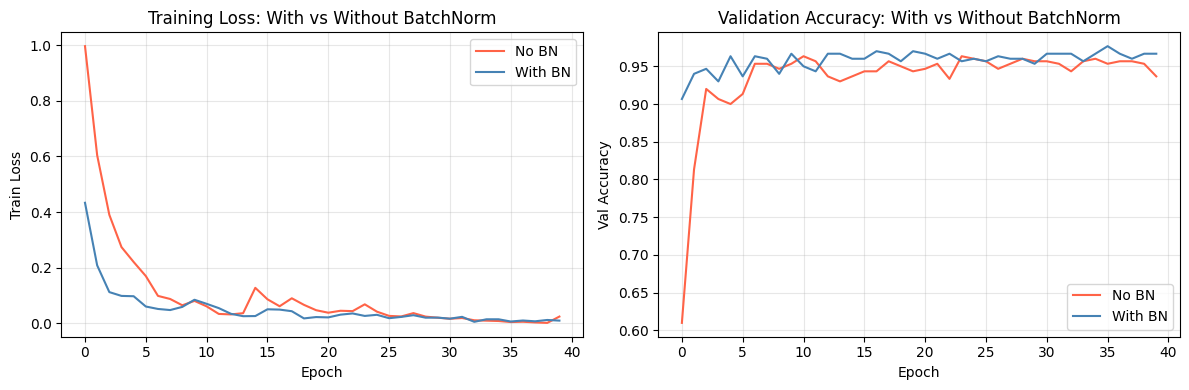

Final val acc — No BN: 0.937 | With BN: 0.967


In [ ]:
# ── BN 유무 비교: 깊은 네트워크에서의 학습 안정성 ────────────────

# 데이터 생성 (3-class, 2D)
from sklearn.datasets import make_classification
X_raw, y_raw = make_classification(
    n_samples=1500, n_features=20, n_informative=15,
    n_classes=3, n_clusters_per_class=1, random_state=42
)
X_raw = X_raw.astype(np.float32)
y_raw = y_raw.astype(np.int64)

# Train / Val split
X_tr, X_vl = X_raw[:1200], X_raw[1200:]
y_tr, y_vl = y_raw[:1200], y_raw[1200:]

train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
val_ds   = TensorDataset(torch.FloatTensor(X_vl), torch.LongTensor(y_vl))
train_ld = DataLoader(train_ds, batch_size=64, shuffle=True)
val_ld   = DataLoader(val_ds,   batch_size=64, shuffle=False)

# ── 모델 정의 ─────────────────────────────────────────────────────
class DeepNetNoBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, 3)
        )
    def forward(self, x):
        return self.net(x)

class DeepNetBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 3)
        )
    def forward(self, x):
        return self.net(x)

# ── 학습 함수 ─────────────────────────────────────────────────────
def train_and_eval(model, epochs=40, lr=0.1):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)  # Adam → SGD
    tr_losses, vl_accs = [], []
    for _ in range(epochs):
        model.train()
        ep_loss = 0
        for X_b, y_b in train_ld:
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()
        tr_losses.append(ep_loss / len(train_ld))

        model.eval()
        correct = 0
        with torch.no_grad():
            for X_b, y_b in val_ld:
                preds = model(X_b).argmax(dim=1)
                correct += (preds == y_b).sum().item()
        vl_accs.append(correct / len(val_ds))
    return tr_losses, vl_accs

torch.manual_seed(0)
loss_nobn, acc_nobn = train_and_eval(DeepNetNoBN(), lr=0.15)
torch.manual_seed(0)
loss_bn,   acc_bn   = train_and_eval(DeepNetBN(),   lr=0.15)

# ── 시각화 ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_nobn, label="No BN",        color="tomato")
ax1.plot(loss_bn,   label="With BN",      color="steelblue")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Train Loss")
ax1.set_title("Training Loss: With vs Without BatchNorm")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(acc_nobn, label="No BN",         color="tomato")
ax2.plot(acc_bn,   label="With BN",       color="steelblue")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val Accuracy")
ax2.set_title("Validation Accuracy: With vs Without BatchNorm")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Final val acc — No BN: {acc_nobn[-1]:.3f} | With BN: {acc_bn[-1]:.3f}")


---
<a id="section2"></a>
## 2. Softmax 다중분류

### 2-1. 복습: 2주차에서 맛보았던 Softmax

2주차에서 로지스틱 회귀의 다중 클래스 확장으로 Softmax를 잠깐 소개했습니다.  
오늘 완성합니다.

### 2-2. Softmax 함수

클래스가 $K$개일 때, 각 클래스의 **확률**을 출력합니다.

$$\text{Softmax}(z_k) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

- 출력은 항상 $[0, 1]$ 범위
- 모든 클래스 확률의 합 = 1
- 가장 큰 $z_k$가 가장 높은 확률을 가짐

### 2-3. Cross-Entropy Loss

다중분류의 손실 함수는 **Cross-Entropy**입니다.

$$\mathcal{L} = -\sum_{k=1}^{K} y_k \log \hat{p}_k = -\log \hat{p}_{y_{\text{true}}}$$

실제 클래스에 해당하는 **예측 확률의 로그값**을 최대화하는 것과 같습니다.

> **PyTorch 주의사항**:  
> `nn.CrossEntropyLoss()`는 내부적으로 Softmax를 포함합니다.  
> 따라서 모델의 마지막 층에 Softmax를 따로 추가하면 **이중 적용**이 됩니다.
>
> ```python
> # 올바른 방법
> output = model(x)           # raw logits (Softmax 없음)
> loss = criterion(output, y) # CrossEntropyLoss가 softmax 포함
>
> # 예측 시
> probs = F.softmax(output, dim=1)   # 확률이 필요할 때만
> preds = output.argmax(dim=1)       # 클래스만 필요하면 argmax로 충분
> ```

### 2-4. 이진분류 vs 다중분류 비교

| 항목 | 이진분류 (2주차) | 다중분류 |
|------|----------------|---------|
| 출력 뉴런 수 | 1 | K (클래스 수) |
| 활성화 함수 | Sigmoid | Softmax (또는 없음) |
| 손실 함수 | BCELoss | CrossEntropyLoss |
| 출력 해석 | P(y=1) | P(y=k) for each k |


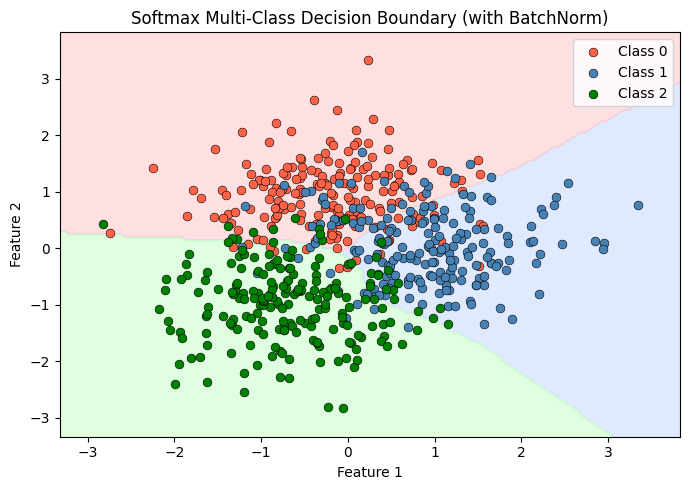

Train accuracy: 0.812


In [ ]:
# ── Softmax 다중분류: 2D 데이터로 결정경계 시각화 ─────────────────

# 3-class 2D 데이터 생성
from sklearn.datasets import make_blobs
X_2d, y_2d = make_blobs(n_samples=600, centers=3,
                         cluster_std=1.2, random_state=42)
X_2d = X_2d.astype(np.float32)
y_2d = y_2d.astype(np.int64)

# 정규화
X_mean, X_std = X_2d.mean(0), X_2d.std(0)
X_2d = (X_2d - X_mean) / X_std

X_t2 = torch.FloatTensor(X_2d)
y_t2 = torch.LongTensor(y_2d)
ds2  = TensorDataset(X_t2, y_t2)
ld2  = DataLoader(ds2, batch_size=32, shuffle=True)

# ── 모델 ──────────────────────────────────────────────────────────
class MultiClassNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 3)   # 3 classes, NO softmax here
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(0)
model_mc  = MultiClassNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mc.parameters(), lr=0.01)

for epoch in range(60):
    model_mc.train()
    for X_b, y_b in ld2:
        optimizer.zero_grad()
        loss = criterion(model_mc(X_b), y_b)
        loss.backward()
        optimizer.step()

# ── 결정경계 시각화 ───────────────────────────────────────────────
model_mc.eval()
h = 0.05
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

with torch.no_grad():
    logits = model_mc(grid)
    Z = logits.argmax(dim=1).numpy().reshape(xx.shape)

colors_bg = ListedColormap(["#ffcccc", "#ccddff", "#ccffcc"])
colors_pt = ["tomato", "steelblue", "green"]

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, cmap=colors_bg, alpha=0.6)
for k in range(3):
    mask = y_2d == k
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                color=colors_pt[k], label=f"Class {k}", edgecolors="k",
                linewidths=0.4, s=40)
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.title("Softmax Multi-Class Decision Boundary (with BatchNorm)")
plt.legend()
plt.tight_layout()  #서브플롯들 사이의 여백을 자동으로 조정해서, 제목·축 레이블이 안 겹치게
plt.show()

# 정확도
with torch.no_grad():
    preds = model_mc(X_t2).argmax(dim=1)
    acc = (preds == y_t2).float().mean().item()
print(f"Train accuracy: {acc:.3f}")


In [ ]:
# ── Softmax 출력 직접 확인 ────────────────────────────────────────
model_mc.eval()
sample = X_t2[:5]
with torch.no_grad():
    logits = model_mc(sample)
    probs  = F.softmax(logits, dim=1)
    preds  = logits.argmax(dim=1)

print("Logits (raw output):")
print(logits.numpy().round(3))
print("\nSoftmax probabilities (sum to 1 per row):")
print(probs.numpy().round(3))
print("\nRow sums:", probs.sum(dim=1).numpy().round(4))
print("\nPredicted classes:", preds.numpy())
print("True labels:      ", y_t2[:5].numpy())


Logits (raw output):
[[-2.877  0.785  0.633]
 [-3.178 -0.633  1.79 ]
 [ 1.241  3.344 -9.778]
 [-7.149  1.872  1.7  ]
 [ 0.513 -0.047 -1.55 ]]

Softmax probabilities (sum to 1 per row):
[[0.014 0.531 0.456]
 [0.006 0.081 0.913]
 [0.109 0.891 0.   ]
 [0.    0.543 0.457]
 [0.589 0.336 0.075]]

Row sums: [1. 1. 1. 1. 1.]

Predicted classes: [1 2 1 1 0]
True labels:       [1 2 1 2 0]


---
<a id="section3"></a>
## 3. 완성 모델: BN + Softmax + Adam + Scheduler

지금까지 배운 요소들을 하나의 실전 모델로 종합합니다.

```
데이터
  ↓
Linear → BatchNorm1d → ReLU    ← 6주차: He 초기화, Dropout
  ↓
Linear → BatchNorm1d → ReLU    ← 7주차: Adam, LR Scheduler
  ↓
Linear (logits)                ← 8주차: Softmax (CrossEntropyLoss 내장)
  ↓
CrossEntropyLoss
```

> 이 구조가 앞으로 9주차(CNN)까지 이어지는 **기본 뼈대**입니다.


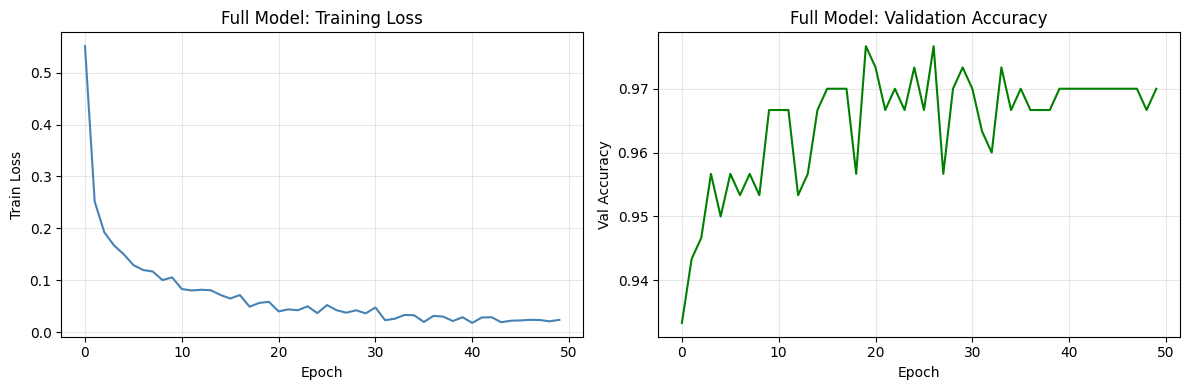

Best val accuracy: 0.977 at epoch 20


In [ ]:
# ── 종합 실전 모델 ────────────────────────────────────────────────
class FullModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, num_classes)
            # No Softmax — CrossEntropyLoss handles it
        )
        # He initialization
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


torch.manual_seed(0)
full_model = FullModel(input_dim=20, hidden_dim=128, num_classes=3)
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(full_model.parameters(), lr=0.01)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

tr_losses, vl_accs = [], []

for epoch in range(50):
    full_model.train()
    ep_loss = 0
    for X_b, y_b in train_ld:
        optimizer.zero_grad()
        loss = criterion(full_model(X_b), y_b)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    tr_losses.append(ep_loss / len(train_ld))

    full_model.eval()
    correct = 0
    with torch.no_grad():
        for X_b, y_b in val_ld:
            correct += (full_model(X_b).argmax(1) == y_b).sum().item()
    vl_accs.append(correct / len(val_ds))
    scheduler.step()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(tr_losses, color="steelblue")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Train Loss")
ax1.set_title("Full Model: Training Loss"); ax1.grid(True, alpha=0.3)

ax2.plot(vl_accs, color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val Accuracy")
ax2.set_title("Full Model: Validation Accuracy"); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Best val accuracy: {max(vl_accs):.3f} at epoch {vl_accs.index(max(vl_accs))+1}")


---
## 📌 Part 1 핵심 정리

| 개념 | 핵심 요약 |
|------|-----------|
| Batch Normalization | 각 층 입력을 미니배치 단위로 정규화 → 학습 안정화, 수렴 가속 |
| BN 위치 | Linear/Conv 다음, 활성화 함수 이전 |
| train/eval 모드 | BN은 모드에 따라 다르게 동작 — 반드시 전환 필요 |
| Softmax | 다중분류 확률 출력, 합 = 1 |
| CrossEntropyLoss | Softmax 내장 — 모델 출력에 Softmax 중복 적용 금지 |
| argmax | 클래스 예측 시 `output.argmax(dim=1)` |

---
## ⏭️ 다음 주 예고 (9주차)

9주차는 **CNN 기초**입니다.
- Convolution 연산의 직관과 수식
- Pooling (Max / Average)
- 기본 CNN 구조 직접 구현
- CIFAR-10 실습

> 오늘의 BN과 Softmax + CrossEntropyLoss는 9주차 CNN에서 그대로 재사용됩니다!


---
# Part 2: 실습

> **목표**: Batch Normalization과 Softmax 다중분류를 직접 구현하며 익힌다.

**[A] 한 줄 채우기** (A-1 ~ A-10): 핵심 한 줄을 완성하세요.  
**[B] 여러 줄 채우기** (B-1): 전체 학습 루프를 완성하세요.


## 공통 데이터 준비

아래 셀을 실행한 뒤 실습을 시작하세요.

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import TensorDataset, DataLoader
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)

# 4-class 분류 데이터 (feature 2개, 시각화 가능)
def make_blobs(n=800, C=4, seed=0):
    torch.manual_seed(seed)
    centers = torch.tensor([[ 2., 2.], [-2., 2.], [-2.,-2.], [ 2.,-2.]])
    X_list, y_list = [], []
    for i in range(C):
        X_list.append(centers[i] + 0.7 * torch.randn(n // C, 2))
        y_list.append(torch.full((n // C,), i, dtype=torch.long))
    X = torch.cat(X_list); y = torch.cat(y_list)
    perm = torch.randperm(n)
    return X[perm], y[perm]

X_all, y_all = make_blobs(800, 4)
X_tr, y_tr   = X_all[:640], y_all[:640]   # train 80%
X_vl, y_vl   = X_all[640:], y_all[640:]   # val   20%

tr_ds = TensorDataset(X_tr, y_tr)
vl_ds = TensorDataset(X_vl, y_vl)
tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True)
vl_ld = DataLoader(vl_ds, batch_size=64, shuffle=False)

print(f"Train: X={X_tr.shape}, y={y_tr.shape}")
print(f"Val  : X={X_vl.shape}, y={y_vl.shape}")
print(f"Steps per epoch: {len(tr_ld)}")

plt.figure(figsize=(5, 5))
plt.scatter(X_tr[:,0], X_tr[:,1], c=y_tr, cmap="Set1", s=12, alpha=0.7)
plt.title("4-Class Dataset"); plt.tight_layout(); plt.show()


---
## [A] 한 줄 채우기

### [A-1] BatchNorm1d 삽입

아래 모델의 빈칸에 `nn.BatchNorm1d`를 올바른 크기로 삽입하세요.  
위치: `Linear(2, 64)` 직후, `ReLU` 이전.


In [ ]:
model_a1 = nn.Sequential(
    nn.Linear(2, 64),
    ______,          # [A-1] BatchNorm1d 삽입
    nn.ReLU(),
    nn.Linear(64, 4)
)
print(model_a1)


### [A-2] CrossEntropyLoss 생성

4-class 분류용 loss function을 생성하세요.


In [ ]:
# [A-2] CrossEntropyLoss를 생성하세요
criterion = ______
print(criterion)


### 💡 심화: 왜 CrossEntropyLoss에 Softmax를 내장했을까?

> 관심 있는 학생을 위한 심화 내용입니다. 시험 범위 외입니다.

#### 문제: Sigmoid + BCELoss를 따로 쓰면 왜 불안정한가?

모델 출력(logit) $z$에서 확률 $p$를 거쳐 loss를 계산하면:

$$p = \sigma(z) = \frac{1}{1 + e^{-z}}, \qquad L = -\log(p)$$

$z = -100$ 처럼 매우 음수이면 컴퓨터는 $e^{100}$을 계산하다 **overflow** → $p = 0$ → $\log(0) = -\infty$

#### 해결: 중간 단계($p$)를 건너뛰고 $z$에서 직접 계산

`BCEWithLogitsLoss`는 $p$를 실제로 만들지 않고 아래 형태로 계산합니다:

$$L = \max(z,\,0) - z \cdot y + \log\!\left(1 + e^{-|z|}\right)$$

$|z|$가 아무리 커도 $e^{-|z|} \leq 1$ — overflow 없음.

#### Softmax + CrossEntropyLoss도 동일한 이유

$z \to \text{softmax}(z) \to \log$ 두 단계 대신, **LogSoftmax**를 한 번에:

$$\log\,\text{softmax}(z_k) = z_k - \log\sum_j e^{z_j}$$

$\log\sum_j e^{z_j}$ 계산 시 **max trick**으로 overflow를 막습니다:

$$\log\sum_j e^{z_j} = \max(z) + \log\sum_j e^{z_j - \max(z)}$$

$z_j - \max(z) \leq 0$ 이므로 $e^{z_j - \max(z)} \leq 1$ — 항상 안전.

#### 한 줄 요약

> 수학적으로는 동일하지만, $p$를 실제로 만들지 않고 **수치적으로 안전한 범위에서 한 번에 계산**합니다.  
> 역변환을 두 번 하는 게 아니라, 불안정한 중간 단계를 **건너뛰는** 것입니다.

### [A-3] 다중분류 출력층

클래스 수 C=4일 때 출력층을 완성하세요.  
입력 크기 32, 출력 크기 4. **Softmax는 붙이지 않습니다.**


In [ ]:
C = 4
model_a3 = nn.Sequential(
    nn.Linear(2, 32), nn.ReLU(),
    ______           # [A-3] 출력층 (Softmax 없음)
)
x_test = torch.randn(8, 2)
print("Output shape:", model_a3(x_test).shape)   # 기대값: [8, 4]


### [A-4] CrossEntropyLoss label 형식

`CrossEntropyLoss`에 맞는 label을 만드세요.  
배치 크기 16, 클래스 수 4 — **정수 인덱스, shape [16]**.


In [ ]:
# [A-4] 정수 인덱스 label을 만드세요 (shape [16], 값 범위 0~3)
y_batch = ______
print("shape:", y_batch.shape, "dtype:", y_batch.dtype)


### [A-5] 예측 클래스 추출

logit 출력에서 예측 클래스(argmax)를 구하세요.


In [ ]:
logits = torch.tensor([[2.1, 0.3, -1.2, 0.8],
                        [0.1, 3.2,  0.5, 1.1],
                        [-0.5, 0.2, 2.8, 0.1]])
# [A-5] 각 샘플의 예측 클래스 인덱스를 구하세요
pred_class = ______
print("Predicted:", pred_class)   # 기대값: tensor([0, 1, 2])


### [A-6] 정확도(Accuracy) 계산

예측 클래스와 실제 label을 비교해 정확도를 계산하세요.


In [ ]:
y_pred = torch.tensor([0, 1, 2, 1, 3])
y_true = torch.tensor([0, 1, 1, 1, 3])
# [A-6] 정확도를 계산하세요 (맞은 개수 / 전체)
accuracy = ______
print(f"Accuracy: {accuracy:.2f}")   # 기대값: 0.80


### [A-7] Softmax로 확률 변환

`torch.softmax`를 사용해 logit을 확률로 변환하고, 합이 1인지 확인하세요.


In [ ]:
logits_a7 = torch.tensor([2.0, 1.0, 0.1, -1.0])
# [A-7] softmax로 확률 변환 (dim=0)
probs = ______
print("Probs:", probs)
print(f"Sum  : {probs.sum():.4f}")   # 기대값: 1.0000


### [A-8] model.eval() + no_grad 검증

아래 검증 코드의 두 빈칸을 채우세요.


In [ ]:
model_a8 = nn.Sequential(
    nn.Linear(2, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Linear(32, 4)
)
model_a8.train()   # 일부러 train 모드로 시작

# [A-8a] 평가 모드로 전환
______

with torch.no_grad():
    val_logits = model_a8(X_vl)
    # [A-8b] CrossEntropyLoss로 val loss 계산
    val_loss = ______

print(f"Val loss: {val_loss.item():.4f}")
print(f"BN training mode: {model_a8[1].training}")   # 기대값: False


### [A-9] state_dict 키 확인

BN이 포함된 모델의 `state_dict()` 키를 출력하세요.  
`running_mean`, `running_var`가 포함되어 있는지 확인합니다.


In [ ]:
model_a10 = nn.Sequential(
    nn.Linear(2, 16), nn.BatchNorm1d(16), nn.ReLU(), nn.Linear(16, 4)
)
# [A-10] state_dict()를 가져와 키 목록을 출력하세요
sd = ______
for k in sd.keys():
    print(k)


---
## [B] 여러 줄 채우기


### [B-1] BN + Softmax 전체 학습 루프

아래 `FullClassifier`의 빈칸을 채우고, 완전한 훈련+검증 루프를 완성하세요.

**힌트**
- 모델: `Linear(2,64) → BN → ReLU → Dropout(0.3) → Linear(64,32) → BN → ReLU → Linear(32,4)`
- 옵티마이저: Adam (lr=0.01)
- 스케줄러: StepLR (step_size=10, gamma=0.5)
- 40 epoch, 매 epoch마다 train loss + val accuracy 기록


In [ ]:
class FullClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            ______,             # [B-1-1] BatchNorm1d(64)
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            ______,             # [B-1-2] BatchNorm1d(32)
            nn.ReLU(),
            ______              # [B-1-3] 출력층: 4 classes
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                ______          # [B-1-4] He 초기화

    def forward(self, x):
        return self.net(x)

torch.manual_seed(0)
model_b1 = FullClassifier()
crit_b1  = nn.CrossEntropyLoss()
______   # [B-1-5] optimizer: Adam, lr=0.01
______   # [B-1-6] scheduler: StepLR, step_size=10, gamma=0.5

tr_hist, vl_hist = [], []

for epoch in range(40):
    ______                      # [B-1-7] train mode
    ep_loss = 0
    for X_b, y_b in tr_ld:
        ______                  # [B-1-8] zero_grad
        loss = crit_b1(model_b1(X_b), y_b)
        ______                  # [B-1-9] backward
        ______                  # [B-1-10] optimizer step
        ep_loss += loss.item()
    tr_hist.append(ep_loss / len(tr_ld))

    ______                      # [B-1-11] eval mode
    correct = 0
    with torch.no_grad():
        for X_b, y_b in vl_ld:
            correct += (model_b1(X_b).argmax(1) == y_b).sum().item()
    vl_hist.append(correct / len(vl_ds))
    ______                      # [B-1-12] scheduler step

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(tr_hist, color="steelblue")
ax1.set_title("B-1: Train Loss"); ax1.set_xlabel("Epoch"); ax1.grid(True, alpha=0.3)
ax2.plot(vl_hist, color="green")
ax2.set_title("B-1: Val Accuracy"); ax2.set_xlabel("Epoch"); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Best val accuracy: {max(vl_hist):.3f}")


---
## ✅ 체크리스트

- [ ] `nn.BatchNorm1d`를 `Linear → BN → ReLU` 순서로 올바르게 삽입할 수 있다
- [ ] `model.train()` / `model.eval()` 전환이 BN에서 왜 필요한지 설명할 수 있다
- [ ] `nn.CrossEntropyLoss()`에 Softmax가 내장되어 있어 출력층에 Softmax를 붙이면 안 됨을 안다
- [ ] 다중분류 label은 정수 인덱스(`torch.long`)임을 안다
- [ ] `logits.argmax(dim=1)`로 예측 클래스를 추출할 수 있다
- [ ] `nn.init.kaiming_normal_`로 He 초기화를 적용할 수 있다

---
## 💬 생각해볼 질문

1. **배치 크기가 1일 때 BN을 사용하면 어떤 문제가 생길까?**  
   평균과 분산을 단 1개 샘플로 추정하면 어떻게 될까요?

2. **왜 CrossEntropyLoss는 Softmax를 내장했을까?**  
   수치 안정성(numerical stability) 관점에서 생각해 보세요.

3. **BN과 Dropout을 함께 쓸 때 주의할 점은 무엇일까?**  
   Dropout이 BN의 통계 추정에 어떤 영향을 줄 수 있을지 생각해 보세요.
